In [1]:
# Name: Jackson Irungu Maina
# Reg No: ST61/55297/2025
# Programme: ST61 - Master of Data Science
# School: School of Science and Technology
# Course: Data Mining and Big Data , CSA 806 (Year 1 Sem 2 )
# Task: Module 5

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
df = pd.read_csv('fiia.csv')
# Filter for Kenya
df_kenya = df[df['country'] == 'Kenya'].copy()

In [4]:
# Inspect the dataset
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   country                 23524 non-null  str  
 1   year                    23524 non-null  int64
 2   uniqueid                23524 non-null  str  
 3   bank_account            23524 non-null  str  
 4   location_type           23524 non-null  str  
 5   cellphone_access        23524 non-null  str  
 6   household_size          23524 non-null  int64
 7   age_of_respondent       23524 non-null  int64
 8   gender_of_respondent    23524 non-null  str  
 9   relationship_with_head  23524 non-null  str  
 10  marital_status          23524 non-null  str  
 11  education_level         23524 non-null  str  
 12  job_type                23524 non-null  str  
dtypes: int64(3), str(10)
memory usage: 4.6 MB
None
  country  year    uniqueid bank_account location_type cellphone_access  \
0   Kenya 

In [5]:
# Drop identifiers and columns with no variance or irrelevant for analysis
data = df_kenya.drop(columns=['country', 'uniqueid', 'year'])

In [6]:
# Updated to explicitly include both object and string dtypes
categorical_cols = data.select_dtypes(include=['object', 'string']).columns

In [7]:
# Encode categorical variables using Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [8]:
# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [9]:
# Perform PCA
# Let's reduce it to see how much variance is explained by the first few components
pca = PCA()
pca_result = pca.fit_transform(scaled_data)

In [10]:
# Cumulative Explained Variance
explained_variance = pca.explained_variance_ratio_.cumsum()

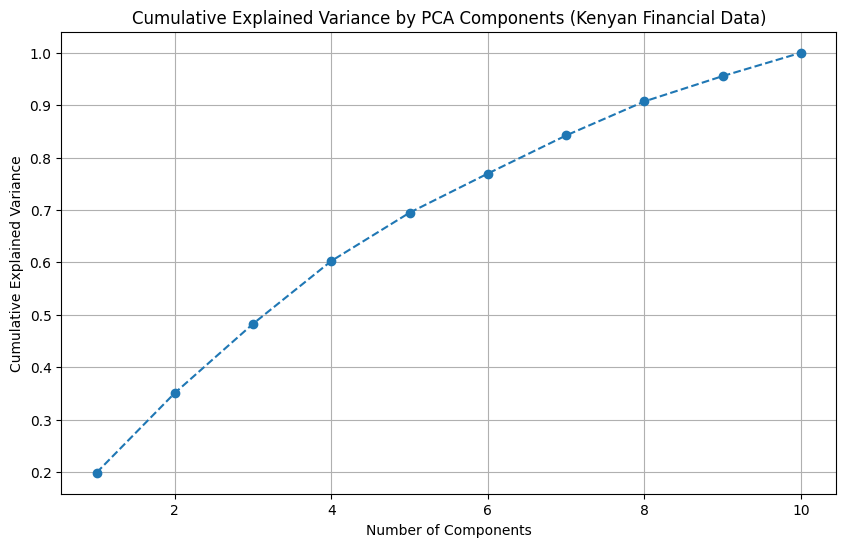

In [11]:
# Plot Explained Variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components (Kenyan Financial Data)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.savefig('pca_variance_plot.png')

In [12]:
# Create a DataFrame for the first 2 Principal Components for illustration
pca_df = pd.DataFrame(data=pca_result[:, :2], columns=['Principal Component 1', 'Principal Component 2'])
# Add back the target variable (bank_account) for visualization context
pca_df['bank_account'] = df_kenya['bank_account'].values

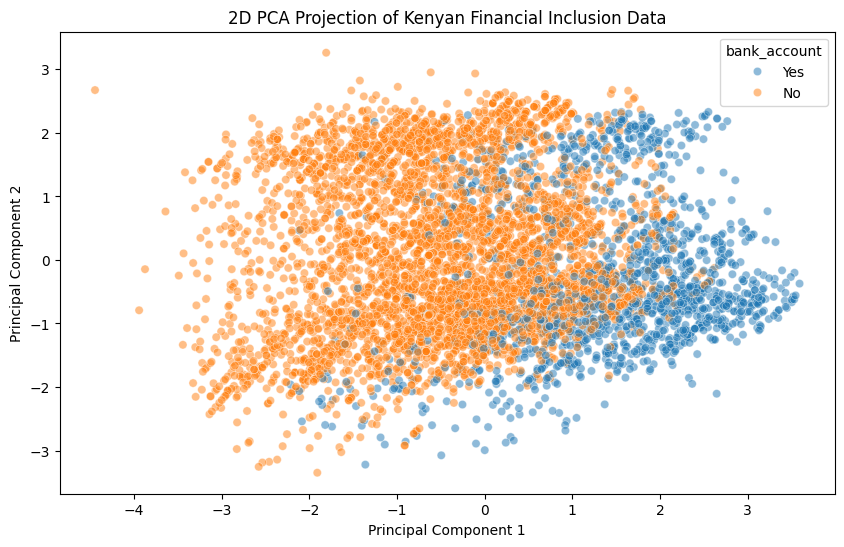

In [13]:
# Plot the transformation in 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='bank_account', data=pca_df, alpha=0.5)
plt.title('2D PCA Projection of Kenyan Financial Inclusion Data')
plt.savefig('pca_2d_projection.png')

In [14]:
# Output the first few rows of the transformation
transformation_sample = pca_df.head(10)
transformation_sample.to_csv('pca_transformation_sample.csv', index=False)

In [15]:
print("Explained Variance Ratio per Component:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio per Component:
[0.19861279 0.15209415 0.13211538 0.11986054 0.09214184 0.07468763
 0.07269972 0.06491345 0.04832573 0.04454877]
